<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
!pip install lime -q
import numpy as np, pandas as pd, joblib, lime, lime.lime_tabular, matplotlib.pyplot as plt, warnings, pickle
from collections import defaultdict
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Setup complete


In [2]:
# CELL 2
rf_model = joblib.load(f'{BASE}/results/models/random_forest.pkl')
data = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_train = data['X_train']; X_test = data['X_test']; y_test = data['y_test']
feature_names = data['feature_names']

np.random.seed(42)
idx30    = np.random.choice(len(X_test), 30, replace=False)
X_sample = X_test[idx30]; y_sample = y_test[idx30]
print(f'✅ Data loaded | features: {feature_names[:5]}...')
print(f'   30 samples: {y_sample.sum()} attacks, {(y_sample==0).sum()} normal')

✅ Data loaded | features: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes']...
   30 samples: 14 attacks, 16 normal


In [3]:
# CELL 3
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, feature_names=feature_names,
    class_names=['Normal','Attack'], mode='classification', random_state=42
)
print('✅ LIME explainer created with real NSL-KDD feature names')

✅ LIME explainer created with real NSL-KDD feature names


Sample 1 | Actual: Attack | Pred: Attack | Conf: 100.00%

Top features:
  flag <= -0.74                           : INCREASES by 0.0581
  wrong_fragment <= -0.09                 : DECREASES by 0.0551
  logged_in <= -0.81                      : INCREASES by 0.0429
  hot <= -0.10                            : DECREASES by 0.0363
  same_srv_rate <= -1.32                  : INCREASES by 0.0350
  num_failed_logins <= -0.03              : DECREASES by 0.0325
  root_shell <= -0.04                     : INCREASES by 0.0310
  count > 0.57                            : INCREASES by 0.0288
  rerror_rate <= -0.37                    : DECREASES by 0.0264
  dst_host_srv_count <= -0.95             : INCREASES by 0.0236
  -0.64 < serror_rate <= 1.60             : INCREASES by 0.0221
  num_file_creations <= -0.03             : DECREASES by 0.0144
  -0.63 < srv_serror_rate <= 1.61         : INCREASES by 0.0128
  dst_host_rerror_rate <= -0.39           : DECREASES by 0.0108
  num_shells <= -0.02           

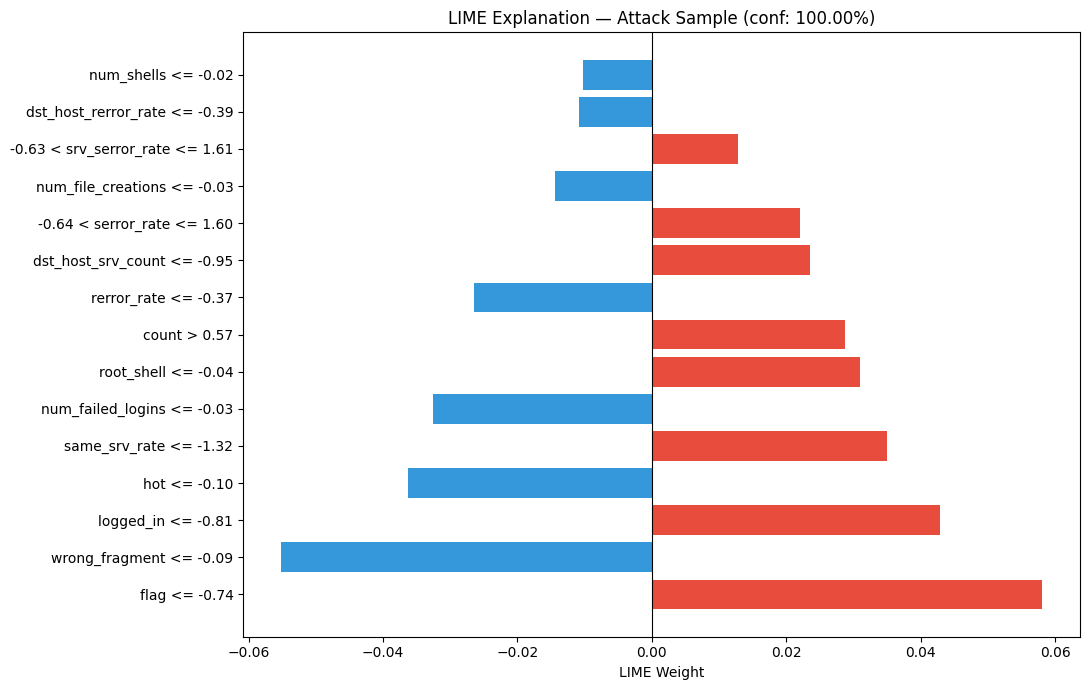

✅ LIME bar plot saved


In [4]:
# CELL 4 — Explain one attack sample
attack_idx = np.where(y_sample == 1)[0]
if len(attack_idx) > 0:
    i = attack_idx[0]
    pred  = rf_model.predict(X_sample[i].reshape(1,-1))[0]
    proba = rf_model.predict_proba(X_sample[i].reshape(1,-1))[0]
    print(f'Sample {i} | Actual: Attack | Pred: {"Attack" if pred==1 else "Normal"} | Conf: {max(proba):.2%}')

    exp = explainer.explain_instance(X_sample[i], rf_model.predict_proba, num_features=15)
    print('\nTop features:')
    for feat, weight in exp.as_list():
        print(f'  {feat:40s}: {"INCREASES" if weight>0 else "DECREASES"} by {abs(weight):.4f}')

    exp.save_to_file(f'{BASE}/results/figures/lime_explanation.html')

    features, weights = zip(*exp.as_list())
    fig, ax = plt.subplots(figsize=(11,7))
    ax.barh(range(len(features)), weights, color=['#e74c3c' if w>0 else '#3498db' for w in weights])
    ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
    ax.set_xlabel('LIME Weight'); ax.set_title(f'LIME Explanation — Attack Sample (conf: {max(proba):.2%})')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/lime_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show(); print('✅ LIME bar plot saved')

In [5]:
# CELL 5 — Explain all 30 samples
print('Explaining 30 samples...')
lime_results = []
for i in range(len(X_sample)):
    pred  = rf_model.predict(X_sample[i].reshape(1,-1))[0]
    proba = rf_model.predict_proba(X_sample[i].reshape(1,-1))[0]
    exp   = explainer.explain_instance(X_sample[i], rf_model.predict_proba, num_features=10)
    lime_results.append({
        'sample_idx': i, 'actual': 'Attack' if y_sample[i]==1 else 'Normal',
        'predicted': 'Attack' if pred==1 else 'Normal',
        'confidence': float(max(proba)), 'explanation': exp.as_list()
    })
    if (i+1) % 5 == 0: print(f'  [{i+1}/30] done')

with open(f'{BASE}/results/lime_results.pkl','wb') as f:
    pickle.dump(lime_results, f)
print('✅ All 30 LIME results saved')

Explaining 30 samples...
  [5/30] done
  [10/30] done
  [15/30] done
  [20/30] done
  [25/30] done
  [30/30] done
✅ All 30 LIME results saved


In [6]:
# CELL 6 — Feature frequency summary
freq = defaultdict(int); impact = defaultdict(list)
for r in lime_results:
    for feat_cond, w in r['explanation']:
        fn = feat_cond.split(' ')[0]
        freq[fn] += 1; impact[fn].append(abs(w))

freq_df = pd.DataFrame([
    {'feature':f,'frequency':c,'mean_impact':np.mean(impact[f])}
    for f,c in freq.items()
]).sort_values('frequency', ascending=False)

print('Most frequently cited features across 30 LIME explanations:')
print(freq_df.head(10).to_string(index=False))
freq_df.to_csv(f'{BASE}/results/metrics/lime_feature_frequency.csv', index=False)
print('✅ LIME frequency summary saved')

Most frequently cited features across 30 LIME explanations:
          feature  frequency  mean_impact
   wrong_fragment         30     0.067534
              hot         29     0.032816
            -1.32         27     0.033175
            -0.74         22     0.058679
            count         19     0.031111
      rerror_rate         19     0.024546
            -0.81         18     0.043941
            -0.01         15     0.059434
       num_shells         13     0.022930
num_failed_logins         13     0.027763
✅ LIME frequency summary saved
